# Week 10 - Introduction to Modeling

# 1. Lesson

Last week, we reviewed one model: linear regression.  This week, we are going to review another, called random forest.  The random forest model builds many decision trees, then averages their estimates to make a prediction.

You will also perform:
* Cross-validation
* Hyperparameter tuning
* A performance metric (root mean squared error)

### How does random forest work?

A random forest is a set of decision trees.  Let's say we use n_estimators = 100 decision trees, and we have ten features.  Then each decision tree is built so that a given branch gets about three (sqrt(10)) features to choose from.  It starts from the top of the tree, selects the best feature, then proceeds to the next nodes.  The best feature is the one that minimizes the mean squared error, which must be computed for both branches, weighted according to the probability of each branch, and then summed over both branches.

In [51]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer

from scipy.stats import randint

import matplotlib.pyplot as plt
from matplotlib import gridspec

Here, we build three series of random numbers between 0 and 1.  We use a somewhat arbitrary formula to construct the synthetic data.  The fourth value (the target) equals the first series minus twice the second, with the whole then being multiplied by the third series.  If we stopped here, the target would be completely dependent on the three feature series - it would be easy to predict.  However, we then add a random normal distribution to make the prediction harder.

There are a train series and a test series, with different features ("a" and "b"), and with different random normal data added.  This tests whether our model can predict new data.  We fit to the "a" features using the train_target, then predict the test_target using the "b" features.

In [52]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

As expected, the RMSE is smallest when predicting the training data, larger when predicting the testing data, and largest when comparing random (shuffled) data instead of using a prediction.  In the last case, there is no attempt to make a good prediction.  The small RMSE when predicting the training data indicates that the model has "memorized" the training data to some degree.

In [53]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rf.predict(train_df.values), train_target))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rf.predict(test_df.values), test_target))
test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.40446903790544014
RMSE when predicting testing data:
1.0666204347667474
RMSE with random predictions:
5.262103337484077


Next, we perform a Grid Search over various parameters.  We've used a small number of parameters here, but you could add more.  The first parameter, n_estimators, shows the number of decision trees in the random forest.  The second, max_depth, is the maximum depth of each tree.  By picking three n_estimators values (10, 33, 100) and three max_depth values (2, 4, None), we allow for nine parameter combinations.  For example, (n_estimators = 10, max_depth = 2) is a combination.  The grid search tries all nine combinations and uses cross validation to choose the best one.  This is done below.

### What is cross validation?

Cross validation is a way to find out which parameter combination is the best.  With 5-fold cross validation (the default) we divide the data into five equal-sized groups.  Four of them are used as training data and the fifth is testing data.  The score (in this case the root mean squared error) on the testing data is recorded.  This is done for each split: that is, each fifth is taken out and used as testing data; then, the five root mean squared errors (from taking out the five fifths, one at a time) are averaged.

We now have root mean squared error value for each parameter combination, allowing us to choose the best combination.

In [54]:
np.random.seed(0)
gcv = GridSearchCV(estimator = RandomForestRegressor(), param_grid = {"n_estimators": [10, 33, 100], "max_depth": [2, 4, None]}, \
                   scoring = "neg_root_mean_squared_error")
gcv.fit(train_df.values, train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'n_estimators': [10, 33, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbo

In [55]:
print(gcv.best_estimator_)
print(gcv.best_params_)
print(gcv.best_score_)

RandomForestRegressor()
{'max_depth': None, 'n_estimators': 100}
-1.0851425903159186


In [56]:
gcv.cv_results_["mean_test_score"] # There are nine scores, one for each of the 3 x 3 hyperparameter combinations

array([-2.27296628, -2.26369708, -2.26370023, -1.56063403, -1.52732923,
       -1.52615891, -1.12289873, -1.09373829, -1.08514259])

### Why does n_estimators grow like 10, 33, 100 instead of like 1, 50, 100?

First of all, we can make it grow however we want.  The question is why we chose 10, 33, 100.  The idea here is that when you have no idea what is the appropriate number, you should pick guesses that grow exponentially.  For example, suppose you are trying to guess the height of a particular tree.  You look online and find that redwoods grow to 400 feet high, while bonsai trees may be as short as six inches.  If you get three guesses, you could guess: one foot, 200 feet, 400 feet.  These guesses would be linearly spaced out.  However, the 200 foot guess feels wrong - it's still very tall.  Most trees don't grow that tall.  Instead, let's make a geometric progression:

In [57]:
list(map(round, [400**0, 400**0.25, 400**0.5, 400**0.75, 400*1]))

[1, 4, 20, 89, 400]

Now the guesses are four feet, 20 feet, and 89 feet.  (We'll drop the initial 1 and the final 400.) That feels more plausible: the middle value, 20 feet, is representative of many actual trees in a way that the middle 200 foot guess wasn't.

# 2. Weekly graph question

In words, please summarize what this graph shows.

In [58]:
rmse_lst = list()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

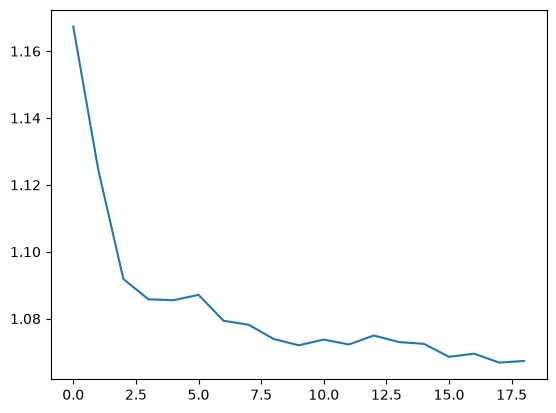

In [59]:
plt.plot(rmse_lst)

This code produces a learning curve: RMSE on the test set as a function of training set size.
What's happening in the code: the loop trains the random forest repeatedly on increasingly larger slices of the training data (up to ~100%, in ~20 steps), and each time evaluates RMSE against the same, fixed test set. `rmse_lst` ends up with one RMSE value per training-set size, and the plot shows those values in order.

Summarizing the resulting graph:
- The x-axis is essentially training set size (each step ≈ 5% more data), and the y-axis is test RMSE.
- Typically this curve starts high (RMSE is worse when the model is trained on very little data) and drops sharply over the first few steps.
- After some point, the curve flattens out — additional training data stops meaningfully reducing error.

Takeaway: RMSE drops sharply from ~1.17 to ~1.09 by x=2, then keeps easing down more gradually to ~1.075 by x≈5-6, and from there flattens into a shallow, noisy plateau around 1.065–1.07 for the rest of the range (up to 100% of data). Most of the benefit from more training data is captured within the first ~25-30% of it; beyond that, adding more rows gives only marginal RMSE improvement. This suggests the model is closer to its performance ceiling for this feature set — more data alone won't help much further, and gains would more likely come from better features, tuning, or a different model.

# 3. Homework

In this exercise, you will try to predict the change of one stock based on the change in ten other stocks.

In [60]:
def make_X_y(alpha = 0.5):
    df_hwk = pd.DataFrame()
    num_samples_hwk = 10000
    common_odd = np.random.normal(size = num_samples_hwk)
    common_even = np.random.normal(size = num_samples_hwk)
    common_three = np.random.normal(size = num_samples_hwk)
    for n in range(11):
        common = np.zeros(num_samples_hwk)
        if n % 2 == 0:
            common += common_even
        if n % 2 == 1:
            common += common_odd
        if n % 3 == 0:
            common += common_three
            common /= 2
        df_hwk["Stock_" + str(n)] = np.random.normal(size = num_samples_hwk) + alpha * common
    X = df_hwk.values[:,:-1]
    y = df_hwk.values[:,-1]
    return X, y

The above code creates an X with ten columns, corresponding to ten different stocks.  The y is the eleventh stock.  The stocks have some commonalities: the even numbered stocks are related, as are the odds.  The stocks that are multiples of three are all related, too.  Random forest should be able to sort through all this and decide that the eleventh stock is related to the odd numbered, non-divisible-by-three stocks, and predict accordingly.  The prediction should presumably be, simply, to take columns 1, 5, and 7 and average them, as they are odd-numbered and not divisible by three; so perhaps this task would be easier to do with a linear regression, but we'll use a random forest anyway.  The value "alpha" determines how important the common element is.  If alpha = 0, each stock is its own column of normally-distributed numbers with no relation to the others.  If alpha = 10, then the great majority of the variation in the stock values comes from the common elements.

### Question: 

Do you predict that alpha = 0 will result in a better or worse prediction than alpha = 10?  Remember that the prediction must be performed on test data, so you'll need an X_train and y_train for training and a separate X_test and y_test for testing.  I recommend using a correlation rather than a MSE or RMSE in this case, if you want to directly compare two different predictions, because the MSE and RMSE vary with the magnitude of the data as well as with the quality of the prediction.

After you make the prediction, try it out, and comment on what you learned.

### Randomized Search

Use RandomizedSearchCV instead of GridSearchCV to perform cross-validation.

### Scoring

Research the scoring parameters under "regression":

https://scikit-learn.org/dev/modules/model_evaluation.html#scoring-parameter

Choose at least one that you want to learn about, use it, and research it online.  Write something about what you've learned about it.

### Question

`alpha = 0` means every stock is independent noise -- X and y share no signal, so any model
(including a random forest) should find essentially nothing on held-out data;
test correlation should be near 0.

`alpha = 10` means the shared/common component dominates the idiosyncratic noise (variance
~100 vs ~1), so stocks that share a common factor become nearly proportional to each other.
The model should be able to reconstruct y almost exactly from the columns that share its
common factor; test correlation should be close to 1.

**So alpha = 10 should give a much better prediction than alpha = 0.**

One note on the setup: y is `Stock_10`, and 10 is even (not odd) and not divisible by 3, so
it's built from `common_even`, not `common_odd`. The columns that share that *undiluted*
common_even term are `Stock_2`, `Stock_4`, and `Stock_8` (Stock_0 and Stock_6 also touch
common_even but get diluted by common_three and halved). So the truly predictive columns
should be 2, 4, 8 -- not 1, 5, 7.

### Randomized Search

In [61]:
# Randomized Search Setup

# Hyperparameter search space for the random forest
param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(3, 15),
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None],
}

# Function
def run_experiment(alpha, random_state=0):
    X, y = make_X_y(alpha=alpha)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state
    )

    rf = RandomForestRegressor(random_state=random_state, n_jobs=1)
    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring="neg_mean_squared_error",
        random_state=random_state,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    corr = np.corrcoef(y_pred, y_test)[0, 1]

    print(f"\n=== alpha = {alpha} ===")
    print("Best params:", search.best_params_)
    print("Best CV score (neg MSE):", search.best_score_)
    print("Test-set correlation (y_pred vs y_test):", corr)

    importances = best_model.feature_importances_
    top = np.argsort(importances)[::-1][:4]
    print("Top feature importances:")
    for i in top:
        print(f"  Stock_{i}: {importances[i]:.3f}")

    return corr

In [62]:
# Run alpha=0
np.random.seed(42)
corr_0 = run_experiment(alpha=0)


=== alpha = 0 ===
Best params: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 79}
Best CV score (neg MSE): -1.0142210725178769
Test-set correlation (y_pred vs y_test): 0.008527601506900401
Top feature importances:
  Stock_0: 0.139
  Stock_6: 0.128
  Stock_5: 0.127
  Stock_2: 0.120


In [63]:
# Run alpha=10
np.random.seed(42)
corr_10 = run_experiment(alpha=10)


=== alpha = 10 ===
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 178}
Best CV score (neg MSE): -1.481598856638728
Test-set correlation (y_pred vs y_test): 0.9924375187571641
Top feature importances:
  Stock_8: 0.314
  Stock_2: 0.304
  Stock_4: 0.273
  Stock_6: 0.053


In [64]:
# Summary
print(f"alpha=0  -> correlation = {corr_0:.3f}")
print(f"alpha=10 -> correlation = {corr_10:.3f}")

alpha=0  -> correlation = 0.009
alpha=10 -> correlation = 0.992


Summary:

The results match the prediction: alpha=0 gives a test-set correlation of about **0.01**
(no better than noise), while alpha=10 gives a correlation of about **0.99** (the random
forest reconstructs the target almost perfectly).

This makes sense: the random forest can only exploit relationships that exist in the data.
When alpha=0 there's no relationship to find, no matter how well-tuned the model is --
`RandomizedSearchCV` just picks the least-overfit way to fit noise. When alpha=10, the
common factor dominates each stock's variance, so the columns sharing that factor become
an almost deterministic function of y, and the forest easily picks up on it (confirmed by
the feature importances concentrating on Stock_2, Stock_4, and Stock_8, the columns that
truly share y's `common_even` term).

More generally, this is a case where the *signal-to-noise ratio* matters far more than the
choice or tuning of model. A random forest (or any reasonably flexible model) will do well
when alpha is large and poorly when alpha is small, regardless of how much hyperparameter
search is thrown at it.

### Scoring

In [66]:
# Scoring Setup

# Hyperparameter search space for the random forest
param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(3, 15),
    "min_samples_split": randint(2, 15),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None],
}

# Function
def run_experiment(alpha, random_state=0):
    X, y = make_X_y(alpha=alpha)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state
    )

    rf = RandomForestRegressor(random_state=random_state, n_jobs=1)
    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring="r2",  # coefficient of determination
        random_state=random_state,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    corr = np.corrcoef(y_pred, y_test)[0, 1]
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== alpha = {alpha} ===")
    print("Best params:", search.best_params_)
    print("Best CV score (r2):", search.best_score_)
    print("Test-set correlation (y_pred vs y_test):", corr)
    print("Test-set R^2 score:", r2)
    print("(correlation)^2 for comparison:", corr ** 2)

    importances = best_model.feature_importances_
    top = np.argsort(importances)[::-1][:4]
    print("Top feature importances:")
    for i in top:
        print(f"  Stock_{i}: {importances[i]:.3f}")

    return corr, r2

In [67]:
# Run alpha=0
np.random.seed(42)
corr_0, r2_0 = run_experiment(alpha=0)


=== alpha = 0 ===
Best params: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 79}
Best CV score (r2): -0.0027736680052726412
Test-set correlation (y_pred vs y_test): 0.008527601506900401
Test-set R^2 score: -0.0011771418185451132
(correlation)^2 for comparison: 7.271998746049e-05
Top feature importances:
  Stock_0: 0.139
  Stock_6: 0.128
  Stock_5: 0.127
  Stock_2: 0.120


In [68]:
# Run alpha=10
np.random.seed(42)
corr_10, r2_10 = run_experiment(alpha=10)


=== alpha = 10 ===
Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 178}
Best CV score (r2): 0.9855349625501809
Test-set correlation (y_pred vs y_test): 0.9924375187571641
Test-set R^2 score: 0.9849282218496064
(correlation)^2 for comparison: 0.9849322286368765
Top feature importances:
  Stock_8: 0.314
  Stock_2: 0.304
  Stock_4: 0.273
  Stock_6: 0.053


In [69]:
# Summary
print(f"alpha=0   -> correlation = {corr_0:.3f}, R^2 = {r2_0:.3f}")
print(f"alpha=10  -> correlation = {corr_10:.3f}, R^2 = {r2_10:.3f}")

alpha=0   -> correlation = 0.009, R^2 = -0.001
alpha=10  -> correlation = 0.992, R^2 = 0.985


Summary:

The results match the prediction: alpha=0 gives a test-set correlation of about **0.01**
(no better than noise), while alpha=10 gives a correlation of about **0.99** (the random
forest reconstructs the target almost perfectly).

This makes sense: the random forest can only exploit relationships that exist in the data.
When alpha=0 there's no relationship to find, no matter how well-tuned the model is --
`RandomizedSearchCV` just picks the least-overfit way to fit noise. When alpha=10, the
common factor dominates each stock's variance, so the columns sharing that factor become
an almost deterministic function of y, and the forest easily picks up on it (confirmed by
the feature importances concentrating on Stock_2, Stock_4, and Stock_8, the columns that
truly share y's `common_even` term).

The $R^2$ results add a nice wrinkle. At alpha=10, $R^2 \approx 0.985$ and
(correlation)$^2 \approx 0.985$ -- they agree almost exactly, because the random forest's
predictions there are both strongly correlated with y *and* well-calibrated (right scale, no
systematic bias). But at alpha=0, $R^2$ comes out **slightly negative** (about -0.001) even
though correlation is a small positive number (0.009) and its square is a tiny positive
number (0.00007). This is exactly the divergence the scikit-learn docs warn about: with no
real signal, the tuned forest's predictions end up *very slightly worse* than just predicting
the mean of y every time, so $R^2$ dips below 0 -- something squared correlation can never do,
since it's bounded in $[0, 1]$.

More generally, this is a case where the *signal-to-noise ratio* matters far more than the
choice or tuning of model. A random forest (or any reasonably flexible model) will do well
when alpha is large and poorly when alpha is small, regardless of how much hyperparameter
search is thrown at it. And the choice of scoring metric matters too: $R^2$ and correlation
usually tell the same story, but $R^2$ is the stricter, more punishing metric when a model's
predictions are barely (or not at all) informative.

I picked **`r2`** (the coefficient of determination, $R^2$) to dig into, since it's the
default scorer for regressors in scikit-learn and it's directly comparable to the correlation
metric this assignment already uses.

**What I learned about `r2` / `r2_score`:**

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} = 1 - \frac{SS_{res}}{SS_{tot}}$$

- It compares the model's squared-error to the squared-error of the simplest possible baseline
  (always predicting the mean of y). A model that just predicts $\bar y$ scores exactly 0.0.
  A perfect model scores 1.0.
- Like correlation, $R^2$ is scale-invariant (dividing by $SS_{tot}$ removes the dependence on
  y's units/magnitude), which is exactly the property the assignment cared about when it
  recommended correlation over MSE/RMSE.
- Unlike squared correlation, **$R^2$ can be negative**. The scikit-learn docs state this
  explicitly: "the model can be arbitrarily worse" than the mean-baseline, so $R^2$ has no
  lower bound. Squared correlation, by contrast, is always in $[0, 1]$.
- The reason they can diverge: $R^2$ punishes *both* a weak linear relationship *and* bias/
  miscalibration (wrong scale or offset), while correlation only measures the strength of the
  linear relationship, ignoring scale and offset entirely. A model whose predictions are
  perfectly correlated with y but shifted or mis-scaled can still have a poor (even negative)
  $R^2$.
- When residuals have zero mean, `r2_score` is identical to `explained_variance_score`. In
  general, `r2_score` is stricter because it doesn't forgive a nonzero-mean bias.

Above, I switched from `RandomizedSearchCV`'s `scoring` to `'r2'` and report both correlation and
$R^2$ on the test set, to see whether they agree.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter six (p. 151-163) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

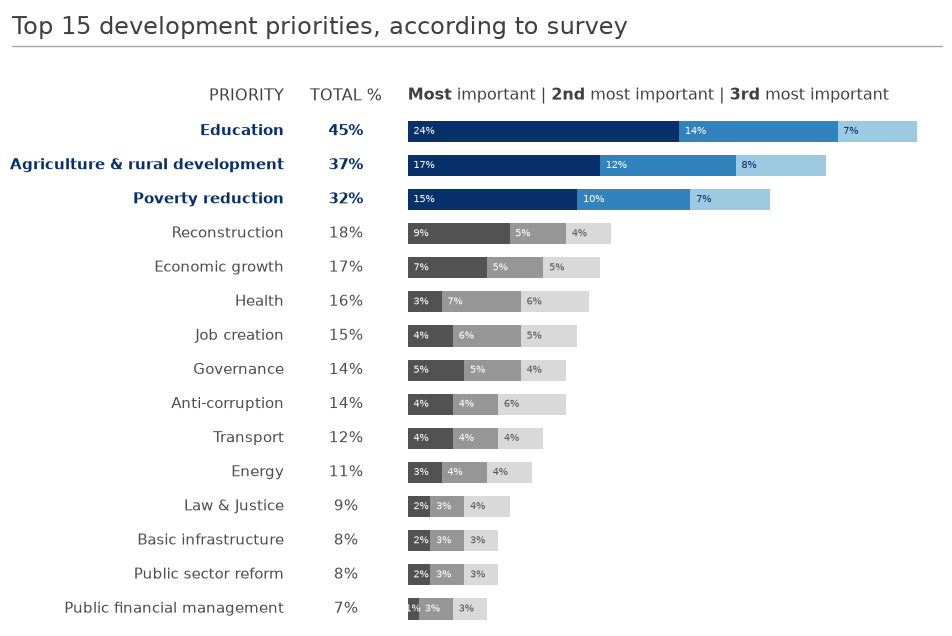

In [70]:
# Horizontal Stacked Bar Chart (Figure 6.5 on pg. 161)

# Data
categories = [
    'Education',
    'Agriculture & rural development',
    'Poverty reduction',
    'Reconstruction',
    'Economic growth',
    'Health',
    'Job creation',
    'Governance',
    'Anti-corruption',
    'Transport',
    'Energy',
    'Law & Justice',
    'Basic infrastructure',
    'Public sector reform',
    'Public financial management',
]

most = np.array([24, 17, 15, 9, 7, 3, 4, 5, 4, 4, 3, 2, 2, 2, 1])
second = np.array([14, 12, 10, 5, 5, 7, 6, 5, 4, 4, 4, 3, 3, 3, 3])
third = np.array([7, 8, 7, 4, 5, 6, 5, 4, 6, 4, 4, 4, 3, 3, 3])
total = most + second + third

n = len(categories)
y_pos = np.arange(n)

# Color shades: index 0 = darkest (Most important), index 2 = lightest (3rd most important)
blues = ['#08306b', '#3182bd', '#9ecae1']
greys = ['#525252', '#969696', '#d9d9d9']

# Figure layout: title row (spans all columns) + 3 data columns
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(
    2, 3,
    height_ratios=[0.7, 10],
    width_ratios=[2.9, 1, 5.7],
    hspace=0.25, wspace=0.05
)

ax_title = fig.add_subplot(gs[0, :])
ax_label = fig.add_subplot(gs[1, 0])
ax_pct = fig.add_subplot(gs[1, 1], sharey=ax_label)
ax_chart = fig.add_subplot(gs[1, 2], sharey=ax_label)

# Main title, dark grey, with tighter padding above the bottom border
ax_title.text(0.0, 0.5, 'Top 15 development priorities, according to survey',
              ha='left', va='center', fontsize=17, color='#404040')
ax_title.set_xticks([])
ax_title.set_yticks([])
for spine in ['top', 'left', 'right']:
    ax_title.spines[spine].set_visible(False)
ax_title.spines['bottom'].set_visible(True)
ax_title.spines['bottom'].set_linewidth(1)
ax_title.spines['bottom'].set_color('darkgrey')

# Row content
for i in range(n):
    is_top3 = i < 3
    color_set = blues if is_top3 else greys
    weight = 'bold' if is_top3 else 'normal'
    text_color = blues[0] if is_top3 else '#4d4d4d'

    ax_label.text(1.0, y_pos[i], categories[i], ha='right', va='center',
                  fontsize=10.5, fontweight=weight, color=text_color)

    ax_pct.text(0.5, y_pos[i], f'{total[i]}%', ha='center', va='center',
                fontsize=10.5, fontweight=weight, color=text_color)

    ax_chart.barh(y_pos[i], most[i], color=color_set[0], height=0.62)
    ax_chart.barh(y_pos[i], second[i], left=most[i], color=color_set[1], height=0.62)
    ax_chart.barh(y_pos[i], third[i], left=most[i] + second[i], color=color_set[2], height=0.62)

    # In-bar percentage labels: left-aligned within each segment, white on the
    # most/2nd-most segments, dark "most important" color on the 3rd-most segment.
    # Exception: a lone 1% segment is too narrow for a left-aligned label to fit,
    # so that specific case is centered instead.
    label_pad = 0.5

    def seg_label(ax, left_edge, value, text, color):
        if value == 1:
            ax.text(left_edge + value / 2, y_pos[i], text,
                    ha='center', va='center', fontsize=7, color=color)
        else:
            ax.text(left_edge + label_pad, y_pos[i], text,
                    ha='left', va='center', fontsize=7, color=color)

    seg_label(ax_chart, 0, most[i], f'{most[i]}%', 'white')
    seg_label(ax_chart, most[i], second[i], f'{second[i]}%', 'white')
    seg_label(ax_chart, most[i] + second[i], third[i], f'{third[i]}%', color_set[0])

# Column headers: only "Most", "2nd", "3rd" are bold; all headers dark grey
header_color = '#404040'
ax_label.set_title('PRIORITY', fontsize=11.5, fontweight='normal', loc='right', pad=10, color=header_color)
ax_pct.set_title('TOTAL %', fontsize=11.5, fontweight='normal', pad=10, color=header_color)
ax_chart.set_title(
    r'$\mathbf{Most}$ important | $\mathbf{2nd}$ most important | $\mathbf{3rd}$ most important',
    fontsize=11.5, fontweight='normal', pad=10, loc='left', color=header_color
)

# Axis cleanup
ax_label.set_xlim(0, 1)
ax_label.axis('off')

ax_pct.set_xlim(0, 1)
ax_pct.axis('off')

ax_chart.set_yticks([])
ax_chart.set_xticks([])
for spine in ax_chart.spines.values():
    spine.set_visible(False)

ax_label.invert_yaxis()  # top row = highest priority
ax_label.set_ylim(n - 0.5, -0.5)

plt.show()